# HRF Benchmark Report


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [ ]:
# After running run_comparative_benchmark() for each dataset,
# collected the results in this dictionary format.
# Just copied the accuracy numbers from raw logs.

benchmark_results = {
    "EEG Eye State": {
        "HRF Ultimate (GPU)": 0.9266,
        "SVM (RBF)":          0.8533,
        "Random Forest":      0.8950,
        "XGBoost":            0.8950,
    },
    "Phoneme": {
        "HRF Ultimate (GPU)": 0.9200,
        "SVM (RBF)":          0.8166,
        "Random Forest":      0.9100,
        "XGBoost":            0.9150,
    },
    "Wall-Following Robot": {
        "HRF Ultimate (GPU)": 0.9966,
        "SVM (RBF)":          0.8850,
        "Random Forest":      0.9950,
        "XGBoost":            0.9966,
    },
    "Electricity": {
        "HRF Ultimate (GPU)": 0.8533,
        "SVM (RBF)":          0.7800,
        "Random Forest":      0.8400,
        "XGBoost":            0.8316,
    },
    "Gas Sensor Drift": {
        "HRF Ultimate (GPU)": 0.9883,
        "SVM (RBF)":          0.9366,
        "Random Forest":      0.9883,
        "XGBoost":            0.9783,
    },
    "Japanese Vowels": {
        "HRF Ultimate (GPU)": 0.9800,
        "SVM (RBF)":          0.9783,
        "Random Forest":      0.9433,
        "XGBoost":            0.9500,
    },
    "Gesture Phase": {
        "HRF Ultimate (GPU)": 0.7033,
        "SVM (RBF)":          0.5500,
        "Random Forest":      0.6816,
        "XGBoost":            0.6716,
    },
    "Mfeat-Fourier": {
        "HRF Ultimate (GPU)": 0.8950,
        "SVM (RBF)":          0.8775,
        "Random Forest":      0.8575,
        "XGBoost":            0.8725,
    },
    "Optdigits": {
        "HRF Ultimate (GPU)": 0.9816,
        "SVM (RBF)":          0.9900,
        "Random Forest":      0.9916,
        "XGBoost":            0.9850,
    },
    "Solar Flare Evolution": {
        "HRF Ultimate (GPU)": 0.7777,
        "SVM (RBF)":          0.7777,
        "Random Forest":      0.7460,
        "XGBoost":            0.7301,
    },
    "Texture Analysis": {
        "HRF Ultimate (GPU)": 1.0000,
        "SVM (RBF)":          0.9046,
        "Random Forest":      0.9826,
        "XGBoost":            0.9971,
    },
    "Steel Plates Faults": {
        "HRF Ultimate (GPU)": 1.0000,
        "SVM (RBF)":          0.9948,
        "Random Forest":      0.9922,
        "XGBoost":            1.0000,
    },
    "HTRU2 Pulsar Detection": {
        "HRF Ultimate (GPU)": 0.7668,
        "SVM (RBF)":          0.7772,
        "Random Forest":      0.7668,
        "XGBoost":            0.7772,
    },
    "Madelon": {
        "HRF Ultimate (GPU)": 0.8500,
        "SVM (RBF)":          0.5980,
        "Random Forest":      0.6961,
        "XGBoost":            0.7961,
    },
    "Bioresponse": {
        "HRF Ultimate (GPU)": 0.8300,
        "SVM (RBF)":          0.7650,
        "Random Forest":      0.8200,
        "XGBoost":            0.8000,
    },
    "Higgs Boson": {
        "HRF Ultimate (GPU)": 0.7016,
        "SVM (RBF)":          0.6650,
        "Random Forest":      0.6866,
        "XGBoost":            0.6666,
    },
    "Magic Telescope": {
        "HRF Ultimate (GPU)": 0.8850,
        "SVM (RBF)":          0.8633,
        "Random Forest":      0.8833,
        "XGBoost":            0.8766,
    },
    "Musk v2": {
        "HRF Ultimate (GPU)": 1.0000,
        "SVM (RBF)":          0.9966,
        "Random Forest":      0.9983,
        "XGBoost":            1.0000,
    },
    "Satimage": {
        "HRF Ultimate (GPU)": 0.9416,
        "SVM (RBF)":          0.8816,
        "Random Forest":      0.9366,
        "XGBoost":            0.9233,
    },
    "Letter Recognition": {
        "HRF Ultimate (GPU)": 0.9250,
        "SVM (RBF)":          0.8633,
        "Random Forest":      0.9133,
        "XGBoost":            0.9033,
    },
}

# Model names and dataset names (auto-extracted)
MODEL_NAMES   = list(list(benchmark_results.values())[0].keys())
DATASET_NAMES = list(benchmark_results.keys())
HRF_NAME      = "HRF Ultimate (GPU)"

print(f"✅ Results loaded for {len(DATASET_NAMES)} datasets")
print(f"   Models tracked : {MODEL_NAMES}")
print(f"   Datasets       : {DATASET_NAMES}")

✅ Results loaded for 20 datasets
   Models tracked : ['HRF Ultimate (GPU)', 'SVM (RBF)', 'Random Forest', 'XGBoost']
   Datasets       : ['EEG Eye State', 'Phoneme', 'Wall-Following Robot', 'Electricity', 'Gas Sensor Drift', 'Japanese Vowels', 'Gesture Phase', 'Mfeat-Fourier', 'Optdigits', 'Solar Flare Evolution', 'Texture Analysis', 'Steel Plates Faults', 'HTRU2 Pulsar Detection', 'Madelon', 'Bioresponse', 'Higgs Boson', 'Magic Telescope', 'Musk v2', 'Satimage', 'Letter Recognition']


In [ ]:
# Clean Summary Table
# ────────────────────────────

def print_summary_table(results, hrf_name):
    """
    Prints a clean per-dataset comparison table.
    Shows each model's accuracy and HRF's margin over best baseline.
    """

    print("\n" + "=" * 72)
    print("   HRF BENCHMARK — DATASET-WISE SUMMARY")
    print("=" * 72)

    all_models = list(list(results.values())[0].keys())

    # Header row
    header = f"{'Dataset':<24}"
    for model in all_models:
        short = model[:10]
        header += f"  {short:^10}"
    header += f"  {'HRF Margin':^11}  {'Winner':^8}"
    print(header)
    print("-" * 72)

    # One row per dataset
    for dataset, scores in results.items():
        hrf_acc = scores[hrf_name]

        # Best baseline (excluding HRF)
        baselines    = {k: v for k, v in scores.items() if k != hrf_name}
        best_bl_acc  = max(baselines.values())
        margin       = hrf_acc - best_bl_acc
        winner       = "✅ HRF" if margin > 0 else "❌ BL"

        row = f"{dataset:<24}"
        for model in all_models:
            acc = scores.get(model, 0)
            row += f"  {acc*100:^10.2f}"
        row += f"  {margin*100:^+11.2f}  {winner:^8}"
        print(row)

    print("-" * 72)

    # Footer: column average
    avg_row = f"{'AVERAGE':<24}"
    for model in all_models:
        avg = np.mean([s[model] for s in results.values() if model in s])
        avg_row += f"  {avg*100:^10.2f}"
    print(avg_row)
    print("=" * 72)


print_summary_table(benchmark_results, HRF_NAME)


   HRF BENCHMARK — DATASET-WISE SUMMARY
Dataset                   HRF Ultima  SVM (RBF)   Random For   XGBoost    HRF Margin    Winner 
------------------------------------------------------------------------
EEG Eye State               92.66       85.33       89.50       89.50        +3.16      ✅ HRF  
Phoneme                     92.00       81.66       91.00       91.50        +0.50      ✅ HRF  
Wall-Following Robot        99.66       88.50       99.50       99.66        +0.00       ❌ BL  
Electricity                 85.33       78.00       84.00       83.16        +1.33      ✅ HRF  
Gas Sensor Drift            98.83       93.66       98.83       97.83        +0.00       ❌ BL  
Japanese Vowels             98.00       97.83       94.33       95.00        +0.17      ✅ HRF  
Gesture Phase               70.33       55.00       68.16       67.16        +2.17      ✅ HRF  
Mfeat-Fourier               89.50       87.75       85.75       87.25        +1.75      ✅ HRF  
Optdigits             

In [ ]:
# Overall Performance Summary
# ─────────────────────────────────────

def print_overall_summary(results, hrf_name):
    """
    Prints wins, losses, average margin, and per-model averages.
    """

    all_models = list(list(results.values())[0].keys())
    datasets   = list(results.keys())

    wins   = 0
    losses = 0
    margins = []

    for dataset, scores in results.items():
        hrf_acc     = scores[hrf_name]
        baselines   = {k: v for k, v in scores.items() if k != hrf_name}
        best_bl_acc = max(baselines.values())
        margin      = hrf_acc - best_bl_acc
        margins.append(margin)
        if margin > 0:
            wins += 1
        else:
            losses += 1

    print("\n" + "=" * 55)
    print("   OVERALL PERFORMANCE SUMMARY")
    print("=" * 55)
    print(f"  Total Datasets   : {len(datasets)}")
    print(f"  HRF Wins         : {wins}  ({wins/len(datasets)*100:.0f}%)")
    print(f"  HRF Losses       : {losses}  ({losses/len(datasets)*100:.0f}%)")
    print(f"  Avg HRF Margin   : {np.mean(margins)*100:+.2f}%")

    best_idx  = int(np.argmax(margins))
    worst_idx = int(np.argmin(margins))
    print(f"  Best Dataset     : {datasets[best_idx]}  ({margins[best_idx]*100:+.2f}%)")
    print(f"  Hardest Dataset  : {datasets[worst_idx]}  ({margins[worst_idx]*100:+.2f}%)")

    print("\n  Average Accuracy per Model:")
    print("  " + "-" * 45)

    avg_scores = []
    for model in all_models:
        avg = np.mean([s[model] for s in results.values() if model in s])
        avg_scores.append((model, avg))

    # Sort highest to lowest
    avg_scores.sort(key=lambda x: -x[1])

    for rank, (model, avg) in enumerate(avg_scores, 1):
        bar = "█" * int(avg * 25)
        tag = " ← HRF" if model == hrf_name else ""
        print(f"  {rank}. {model:<24} {avg*100:.2f}%  {bar}{tag}")

    print("=" * 55)


print_overall_summary(benchmark_results, HRF_NAME)


   OVERALL PERFORMANCE SUMMARY
  Total Datasets   : 20
  HRF Wins         : 13  (65%)
  HRF Losses       : 7  (35%)
  Avg HRF Margin   : +0.85%
  Best Dataset     : Madelon  (+5.39%)
  Hardest Dataset  : HTRU2 Pulsar Detection  (-1.04%)

  Average Accuracy per Model:
  ---------------------------------------------
  1. HRF Ultimate (GPU)       89.61%  ██████████████████████ ← HRF
  2. XGBoost                  87.83%  █████████████████████
  3. Random Forest            87.62%  █████████████████████
  4. SVM (RBF)                83.77%  ████████████████████


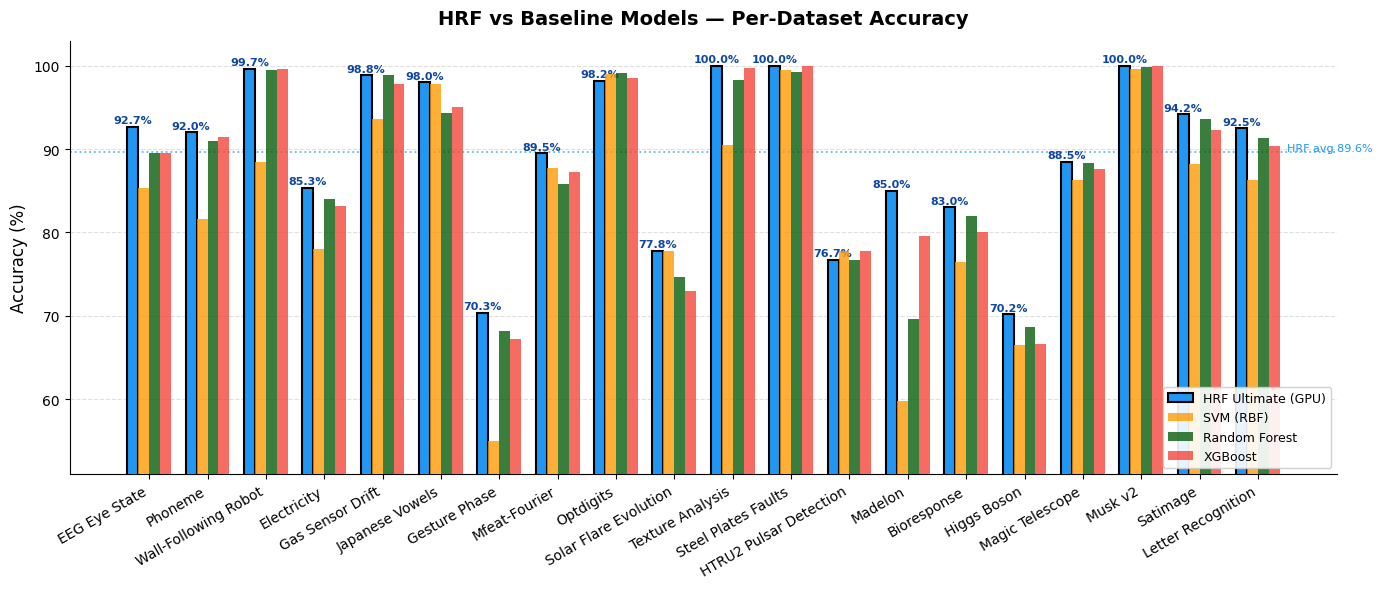

✅ Saved → fig1_per_dataset_bars.png


In [ ]:
# Figure 1 — Per-Dataset Grouped Bar Chart
# ──────────────────────────────────────────────────
# Shows HRF vs all baselines for every dataset side by side.

def plot_per_dataset_bars(results, hrf_name, save_path="fig1_per_dataset_bars.png"):

    datasets    = list(results.keys())
    all_models  = list(list(results.values())[0].keys())
    n_datasets  = len(datasets)
    n_models    = len(all_models)

    # Colours: HRF = blue, others = distinct palette
    palette = ["#2196F3", "#FF9800", "#035A06", "#F44336",
               "#8900A1", "#152224", "#FFCFC1"]
    colour_map = {m: palette[i % len(palette)] for i, m in enumerate(all_models)}

    fig, ax = plt.subplots(figsize=(14, 6))

    x     = np.arange(n_datasets)
    width = 0.75 / n_models

    for i, model in enumerate(all_models):
        accs   = [results[d].get(model, 0) * 100 for d in datasets]
        offset = (i - n_models / 2 + 0.5) * width
        is_hrf = (model == hrf_name)

        bars = ax.bar(
            x + offset,
            accs,
            width      = width,
            color      = colour_map[model],
            edgecolor  = "black" if is_hrf else "none",
            linewidth  = 1.5    if is_hrf else 0,
            alpha      = 1.0    if is_hrf else 0.78,
            label      = model,
            zorder     = 3,
        )

        # Print accuracy value on top of HRF bars only
        if is_hrf:
            for bar in bars:
                h = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + 0.2,
                    f"{h:.1f}%",
                    ha="center", va="bottom",
                    fontsize=8, fontweight="bold", color="#0D47A1"
                )

    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=30, ha="right", fontsize=10)
    ax.set_ylabel("Accuracy (%)", fontsize=12)
    ax.set_title("HRF vs Baseline Models — Per-Dataset Accuracy",
                 fontsize=14, fontweight="bold", pad=12)

    # Y-axis: start just below the lowest value
    all_accs = [v * 100 for d in results.values() for v in d.values()]
    ax.set_ylim(max(0, min(all_accs) - 4), 103)

    ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)

    # Dashed line for HRF average
    hrf_avg = np.mean([results[d][hrf_name] * 100 for d in datasets])
    ax.axhline(hrf_avg, color="#2196F3", linestyle=":", linewidth=1.3, alpha=0.7)
    ax.text(n_datasets - 0.5, hrf_avg + 0.2,
            f"HRF avg {hrf_avg:.1f}%", color="#2196F3", fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved → {save_path}")


plot_per_dataset_bars(benchmark_results, HRF_NAME)

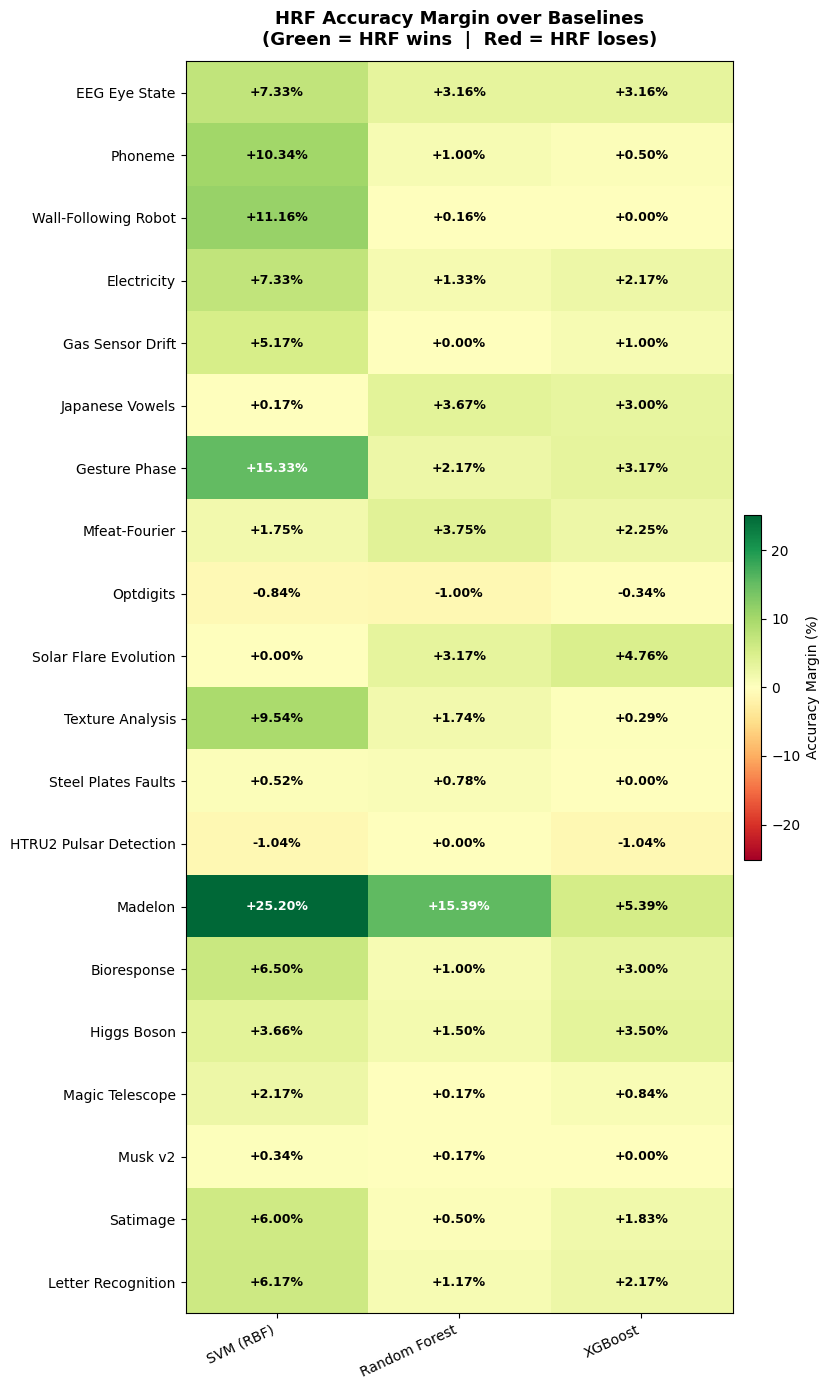

✅ Saved → fig2_margin_heatmap.png


In [ ]:
# Figure 2 — HRF Margin Heatmap
# ─────────────────────────────────────────
# Green  = HRF wins by that margin
# Red    = HRF loses by that margin

def plot_margin_heatmap(results, hrf_name, save_path="fig2_margin_heatmap.png"):

    datasets  = list(results.keys())
    all_models = list(list(results.values())[0].keys())
    baselines = [m for m in all_models if m != hrf_name]

    # Build margin matrix  (rows=datasets, cols=baselines)
    data = np.zeros((len(datasets), len(baselines)))
    for i, dataset in enumerate(datasets):
        hrf_acc = results[dataset][hrf_name]
        for j, bl in enumerate(baselines):
            bl_acc     = results[dataset].get(bl, np.nan)
            data[i, j] = (hrf_acc - bl_acc) * 100

    fig, ax = plt.subplots(figsize=(max(7, len(baselines) * 2.8),
                                    max(4, len(datasets) * 0.7)))

    vmax = max(abs(data.min()), abs(data.max()), 1)
    im   = ax.imshow(data, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")

    # Annotate each cell
    for i in range(len(datasets)):
        for j in range(len(baselines)):
            val  = data[i, j]
            col  = "white" if abs(val) > vmax * 0.55 else "black"
            ax.text(j, i, f"{val:+.2f}%",
                    ha="center", va="center",
                    fontsize=9, color=col, fontweight="bold")

    ax.set_xticks(range(len(baselines)))
    ax.set_xticklabels(baselines, rotation=25, ha="right", fontsize=10)
    ax.set_yticks(range(len(datasets)))
    ax.set_yticklabels(datasets, fontsize=10)
    ax.set_title("HRF Accuracy Margin over Baselines\n"
                 "(Green = HRF wins  |  Red = HRF loses)",
                 fontsize=13, fontweight="bold", pad=12)

    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Accuracy Margin (%)", fontsize=10)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved → {save_path}")


plot_margin_heatmap(benchmark_results, HRF_NAME)

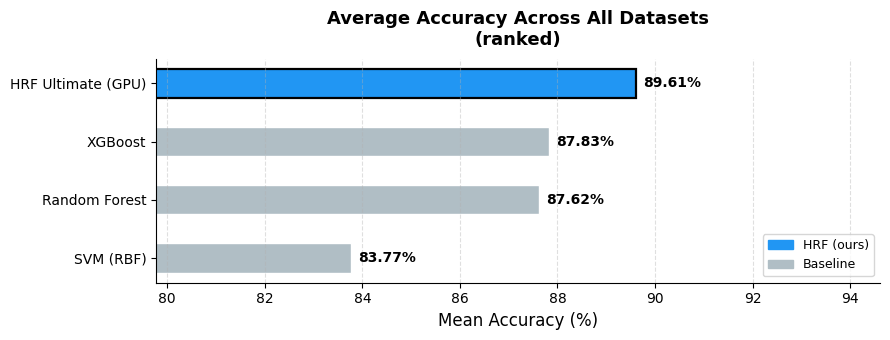

✅ Saved → fig3_average_accuracy.png


In [ ]:
# Figure 3 — Average Accuracy Ranked Horizontal Bar
# ───────────────────────────────────────────────────────────
# Ranks all models by their mean accuracy across all datasets.

def plot_average_accuracy(results, hrf_name, save_path="fig3_average_accuracy.png"):

    all_models = list(list(results.values())[0].keys())

    avg_scores = {}
    for model in all_models:
        vals = [s[model] * 100 for s in results.values() if model in s]
        avg_scores[model] = np.mean(vals) if vals else 0.0

    # Sort lowest → highest (so highest appears at top of horizontal bar)
    ranked  = sorted(avg_scores.items(), key=lambda x: x[1])
    models_ = [x[0] for x in ranked]
    accs_   = [x[1] for x in ranked]

    colours = ["#2196F3" if m == hrf_name else "#B0BEC5" for m in models_]

    fig, ax = plt.subplots(figsize=(9, max(3.5, len(all_models) * 0.85)))

    bars = ax.barh(models_, accs_, color=colours, height=0.5, edgecolor="white")

    # Bold edge on HRF bar
    for bar, model in zip(bars, models_):
        if model == hrf_name:
            bar.set_edgecolor("black")
            bar.set_linewidth(1.6)

    # Value labels
    for bar, val in zip(bars, accs_):
        ax.text(val + 0.15,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}%",
                va="center", fontsize=10, fontweight="bold")

    x_min = max(0, min(accs_) - 4)
    ax.set_xlim(x_min, max(accs_) + 5)
    ax.set_xlabel("Mean Accuracy (%)", fontsize=12)
    ax.set_title("Average Accuracy Across All Datasets\n(ranked)",
                 fontsize=13, fontweight="bold", pad=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    # Legend patch
    hrf_patch = mpatches.Patch(color="#2196F3", label="HRF (ours)")
    bl_patch  = mpatches.Patch(color="#B0BEC5", label="Baseline")
    ax.legend(handles=[hrf_patch, bl_patch], fontsize=9, loc="lower right")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved → {save_path}")


plot_average_accuracy(benchmark_results, HRF_NAME)

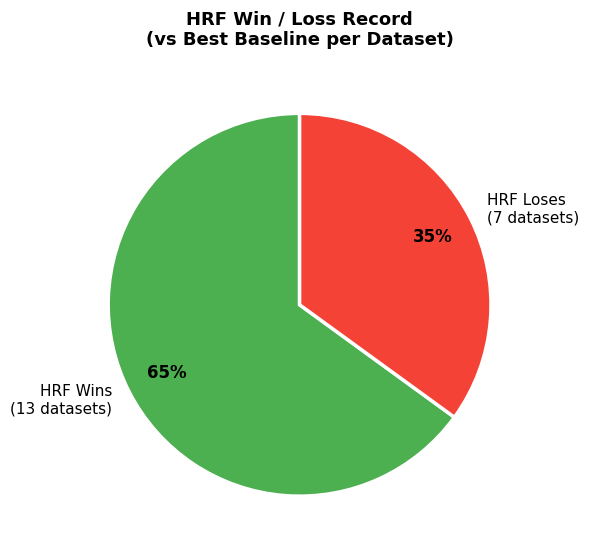

✅ Saved → fig4_win_loss_pie.png


In [ ]:
# Figure 4 — Win / Loss Pie Chart
# ──────────────────────────────────────────
# Shows HRF win/loss record across all datasets.

def plot_win_loss_pie(results, hrf_name, save_path="fig4_win_loss_pie.png"):

    wins   = 0
    losses = 0

    for dataset, scores in results.items():
        hrf_acc   = scores[hrf_name]
        baselines = {k: v for k, v in scores.items() if k != hrf_name}
        best_bl   = max(baselines.values())
        if hrf_acc > best_bl + 0.001:
            wins += 1
        else:
            losses += 1

    sizes  = [wins, losses]
    labels = [f"HRF Wins\n({wins} datasets)",
              f"HRF Loses\n({losses} datasets)"]
    colours = ["#4CAF50", "#F44336"]

    # Remove zero slices
    sizes, labels, colours = zip(
        *[(s, l, c) for s, l, c in zip(sizes, labels, colours) if s > 0]
    ) if any(sizes) else ([], [], [])

    fig, ax = plt.subplots(figsize=(6, 6))
    wedges, texts, autotexts = ax.pie(
        sizes,
        labels      = labels,
        colors      = colours,
        autopct     = "%1.0f%%",
        startangle  = 90,
        pctdistance = 0.78,
        wedgeprops  = {"edgecolor": "white", "linewidth": 2.5},
    )
    for at in autotexts:
        at.set_fontsize(12)
        at.set_fontweight("bold")
    for t in texts:
        t.set_fontsize(11)

    ax.set_title("HRF Win / Loss Record\n(vs Best Baseline per Dataset)",
                 fontsize=13, fontweight="bold", pad=15)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved → {save_path}")


plot_win_loss_pie(benchmark_results, HRF_NAME)

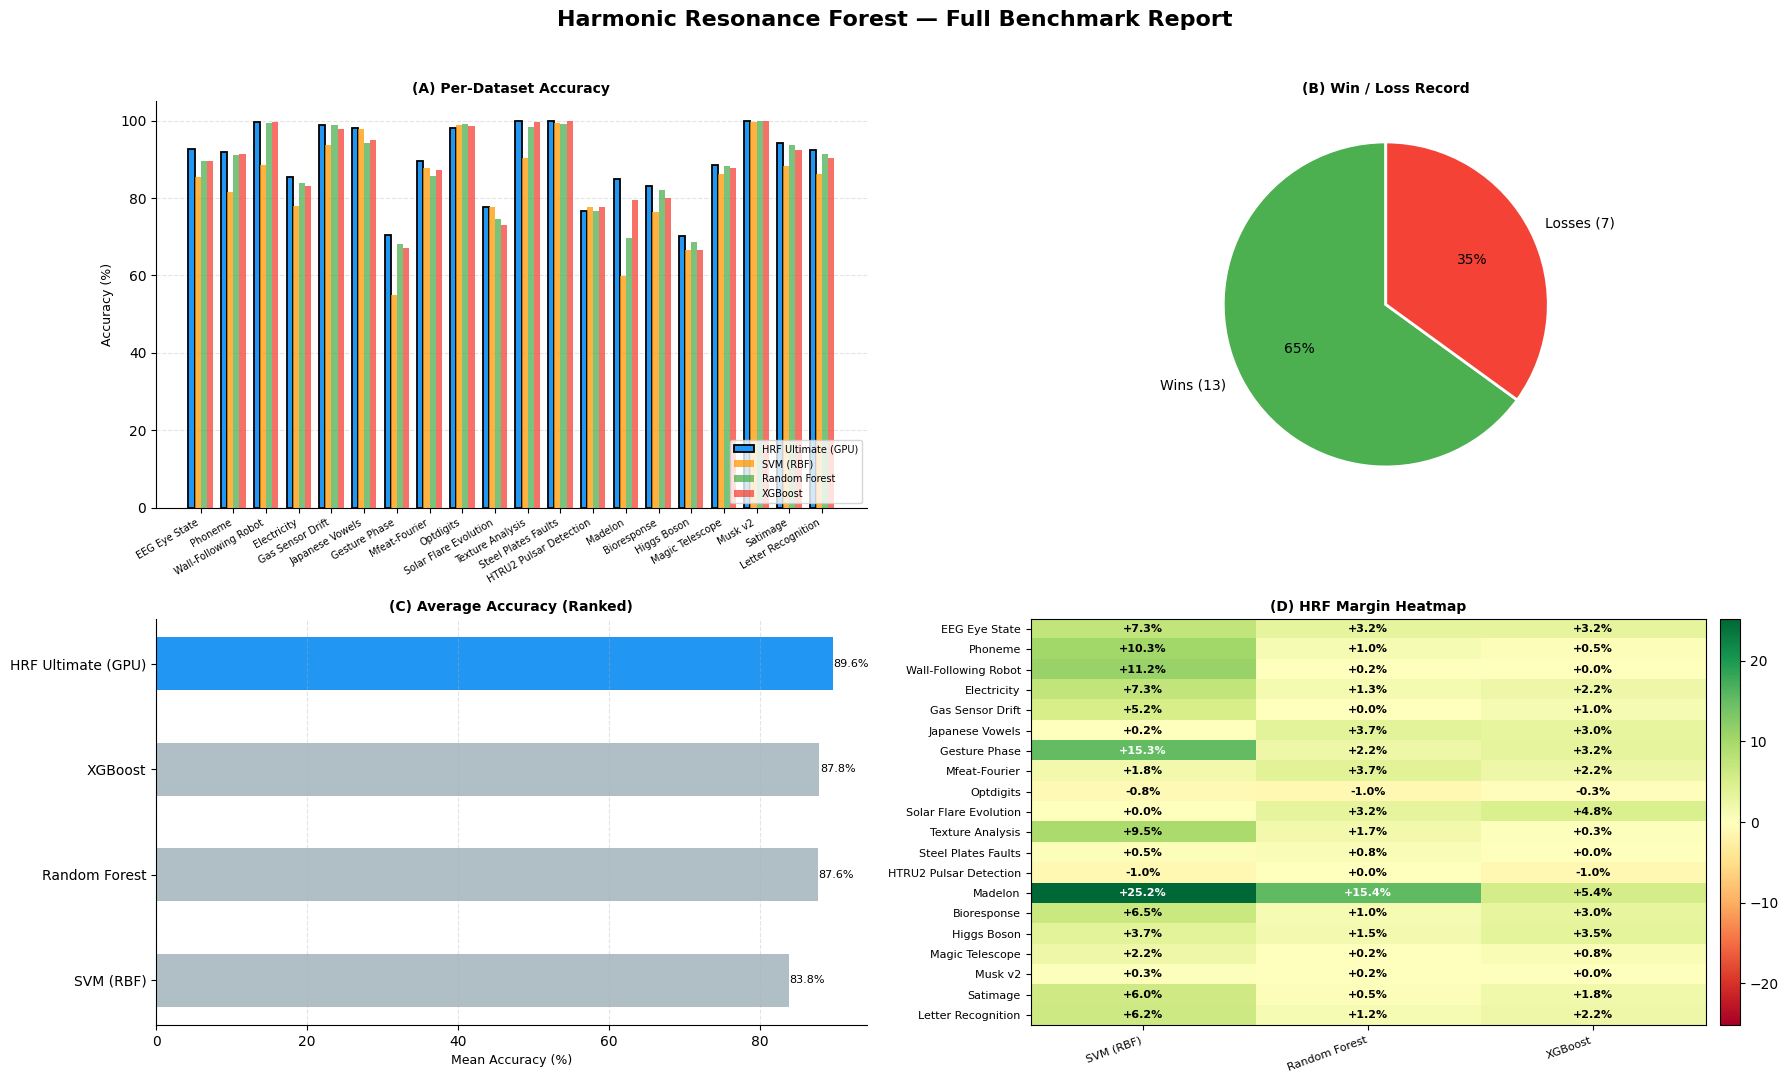

✅ Saved → fig5_composite_report.png


In [ ]:
# Figure 5 — Composite Multi-Panel Figure
# ──────────────────────────────────────────────────
# All 4 charts in one image — ideal for research presentations / README.

def plot_composite(results, hrf_name, save_path="fig5_composite_report.png"):

    datasets   = list(results.keys())
    all_models = list(list(results.values())[0].keys())
    baselines  = [m for m in all_models if m != hrf_name]
    palette    = ["#2196F3", "#FF9800", "#4CAF50", "#F44336", "#9C27B0"]
    colour_map = {m: palette[i % len(palette)] for i, m in enumerate(all_models)}

    fig = plt.figure(figsize=(18, 11))
    fig.suptitle("Harmonic Resonance Forest — Full Benchmark Report",
                 fontsize=16, fontweight="bold", y=0.98)

    # ── Panel A: Per-dataset bars ───────────────────────────────────────
    ax_a = fig.add_subplot(2, 2, 1)
    n_d, n_m = len(datasets), len(all_models)
    x = np.arange(n_d)
    w = 0.75 / n_m

    for i, model in enumerate(all_models):
        accs   = [results[d].get(model, 0) * 100 for d in datasets]
        offset = (i - n_m / 2 + 0.5) * w
        is_hrf = (model == hrf_name)
        ax_a.bar(x + offset, accs, width=w,
                 color     = colour_map[model],
                 edgecolor = "black" if is_hrf else "none",
                 linewidth = 1.3    if is_hrf else 0,
                 alpha     = 1.0    if is_hrf else 0.75,
                 label     = model, zorder=3)

    ax_a.set_xticks(x)
    ax_a.set_xticklabels(datasets, rotation=30, ha="right", fontsize=7)
    ax_a.set_ylabel("Accuracy (%)", fontsize=9)
    ax_a.set_title("(A) Per-Dataset Accuracy", fontsize=10, fontweight="bold")
    ax_a.legend(fontsize=7, loc="lower right")
    ax_a.grid(axis="y", linestyle="--", alpha=0.35)
    ax_a.spines[["top", "right"]].set_visible(False)

    # ── Panel B: Win/Loss pie ───────────────────────────────────────────
    ax_b = fig.add_subplot(2, 2, 2)
    wins   = sum(1 for d in results if
                 results[d][hrf_name] >
                 max(v for k, v in results[d].items() if k != hrf_name) + 0.001)
    losses = len(datasets) - wins
    sizes  = [s for s in [wins, losses] if s > 0]
    lbls   = [l for l, s in
              zip([f"Wins ({wins})", f"Losses ({losses})"],
                  [wins, losses]) if s > 0]
    cols   = [c for c, s in
              zip(["#4CAF50", "#F44336"], [wins, losses]) if s > 0]

    ax_b.pie(sizes, labels=lbls, colors=cols, autopct="%1.0f%%",
             startangle=90,
             wedgeprops={"edgecolor": "white", "linewidth": 2})
    ax_b.set_title("(B) Win / Loss Record", fontsize=10, fontweight="bold")

    # ── Panel C: Average accuracy horizontal bar ────────────────────────
    ax_c = fig.add_subplot(2, 2, 3)
    avg_scores = {
        m: np.mean([results[d][m] * 100 for d in datasets if m in results[d]])
        for m in all_models
    }
    ranked  = sorted(avg_scores.items(), key=lambda x: x[1])
    mods_   = [x[0] for x in ranked]
    accs_   = [x[1] for x in ranked]
    bar_c   = ax_c.barh(mods_, accs_,
                        color=["#2196F3" if m == hrf_name else "#B0BEC5"
                               for m in mods_],
                        height=0.5)
    for bar, val in zip(bar_c, accs_):
        ax_c.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                  f"{val:.1f}%", va="center", fontsize=8)
    ax_c.set_xlabel("Mean Accuracy (%)", fontsize=9)
    ax_c.set_title("(C) Average Accuracy (Ranked)", fontsize=10, fontweight="bold")
    ax_c.spines[["top", "right"]].set_visible(False)
    ax_c.grid(axis="x", linestyle="--", alpha=0.35)

    # ── Panel D: Margin heatmap ─────────────────────────────────────────
    ax_d = fig.add_subplot(2, 2, 4)
    data = np.zeros((len(datasets), len(baselines)))
    for i, d in enumerate(datasets):
        for j, bl in enumerate(baselines):
            data[i, j] = (results[d][hrf_name] - results[d].get(bl, 0)) * 100

    vmax = max(abs(data.min()), abs(data.max()), 1)
    im   = ax_d.imshow(data, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")

    for i in range(len(datasets)):
        for j in range(len(baselines)):
            val = data[i, j]
            col = "white" if abs(val) > vmax * 0.55 else "black"
            ax_d.text(j, i, f"{val:+.1f}%",
                      ha="center", va="center",
                      fontsize=8, color=col, fontweight="bold")

    ax_d.set_xticks(range(len(baselines)))
    ax_d.set_xticklabels(baselines, rotation=20, ha="right", fontsize=8)
    ax_d.set_yticks(range(len(datasets)))
    ax_d.set_yticklabels(datasets, fontsize=8)
    ax_d.set_title("(D) HRF Margin Heatmap", fontsize=10, fontweight="bold")
    plt.colorbar(im, ax=ax_d, fraction=0.03, pad=0.02)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved → {save_path}")


plot_composite(benchmark_results, HRF_NAME)